<a href="https://colab.research.google.com/github/Innovatewithapple/AI-DiscApp/blob/main/REgression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [ ]:
df = pd.read_csv(url)

In [ ]:
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
433,2014,GMC,ACADIA AWD,SUV - STANDARD,3.6,6,A6,X,14.9,10.4,12.9,22,297
899,2014,PORSCHE,CAYMAN S,TWO-SEATER,3.4,6,AM7,Z,11.3,7.9,9.8,29,225
343,2014,FORD,E150 VAN FFV,VAN - CARGO,4.6,8,A4,X,17.7,14.4,16.2,17,373
930,2014,SCION,FR-S,MINICOMPACT,2.0,4,M6,Z,10.9,7.8,9.5,30,218
104,2014,BMW,550i xDRIVE GRAN TURISMO,FULL-SIZE,4.4,8,A8,Z,15.0,9.8,12.7,22,292


In [ ]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [ ]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(5)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
264,5.3,8,18.4,294
161,3.6,6,11.3,260
899,3.4,6,9.8,225
659,3.5,6,11.0,253
926,6.7,12,17.1,393


Check the distribution:

array([[<Axes: title={'center': 'ENGINESIZE'}>,
        <Axes: title={'center': 'CYLINDERS'}>],
       [<Axes: title={'center': 'FUELCONSUMPTION_COMB'}>,
        <Axes: title={'center': 'CO2EMISSIONS'}>]], dtype=object)

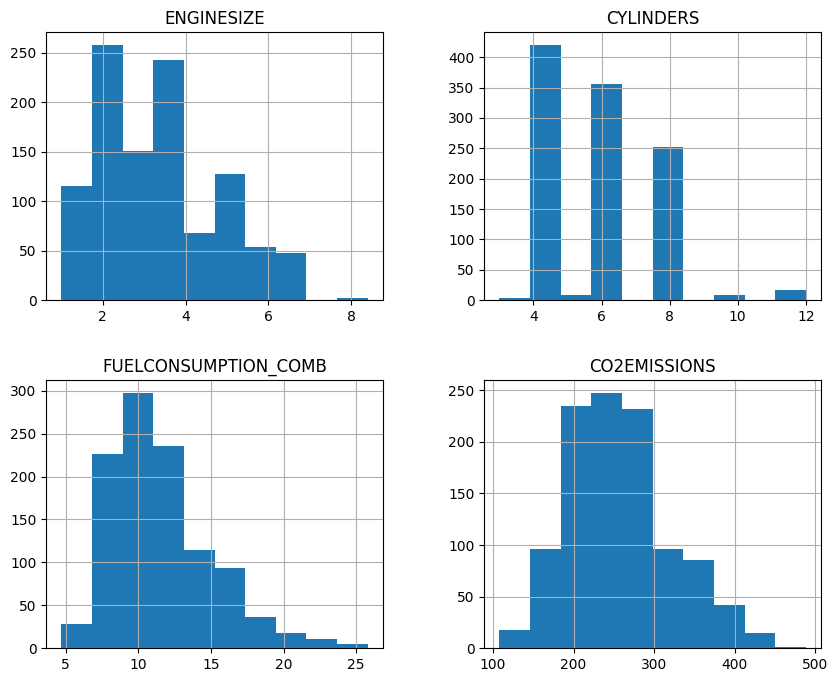

In [ ]:
cdf.hist(figsize=(10,8))

Check how each feature affects CO2

Text(0, 0.5, 'CO2 Emissions')

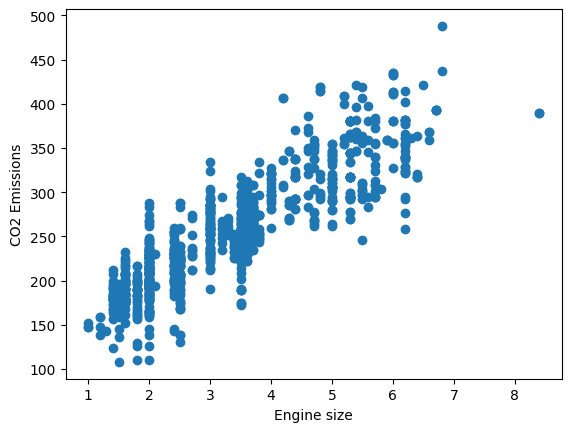

In [ ]:
plt.scatter(cdf.ENGINESIZE,cdf.CO2EMISSIONS)
plt.xlabel('Engine size')
plt.ylabel('CO2 Emissions')

Text(0, 0.5, 'CO2 Emissions')

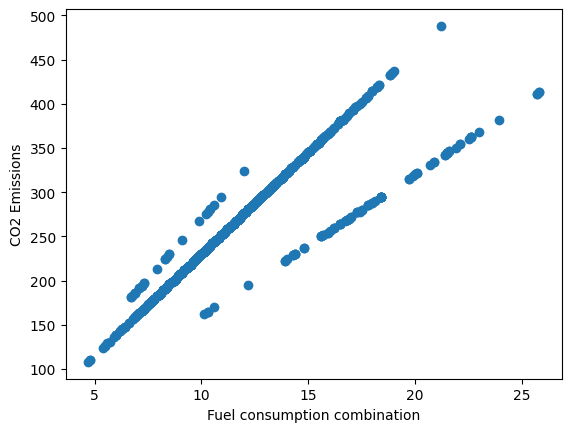

In [ ]:
plt.scatter(cdf.FUELCONSUMPTION_COMB,cdf.CO2EMISSIONS)
plt.xlabel('Fuel consumption combination')
plt.ylabel('CO2 Emissions')

Text(0, 0.5, 'CO2 Emissions')

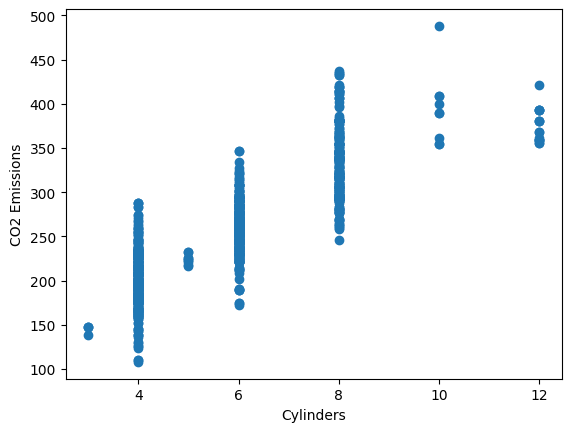

In [ ]:
plt.scatter(cdf.CYLINDERS,cdf.CO2EMISSIONS)
plt.xlabel('Cylinders')
plt.ylabel('CO2 Emissions')

Goal:

Find which feature correlates strongest with CO2

From earlier you probably saw:

Fuel consumption → strongest correlation

Engine size → moderate

Cylinders → weaker

In [ ]:
# Prepare feature and target
X = cdf[['ENGINESIZE']]
y = cdf[['CO2EMISSIONS']]

print(X,y)

      ENGINESIZE
0            2.0
1            2.4
2            1.5
3            3.5
4            3.5
...          ...
1062         3.0
1063         3.2
1064         3.0
1065         3.2
1066         3.2

[1067 rows x 1 columns]       CO2EMISSIONS
0              196
1              221
2              136
3              255
4              244
...            ...
1062           271
1063           264
1064           271
1065           260
1066           294

[1067 rows x 1 columns]


In [ ]:
# Split data
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Train model (Linear regression)
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
# Predict
y_pred = model.predict(X_test)

In [ ]:
# Evaluate (Check matrics)
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
print('MAE:',mean_absolute_error(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2:',r2_score(y_test,y_pred))

MAE: 24.09725741170784
RMSE: 31.399652374309813
R2: 0.7615595731934373


Text(0, 0.5, 'CO2 Emissions')

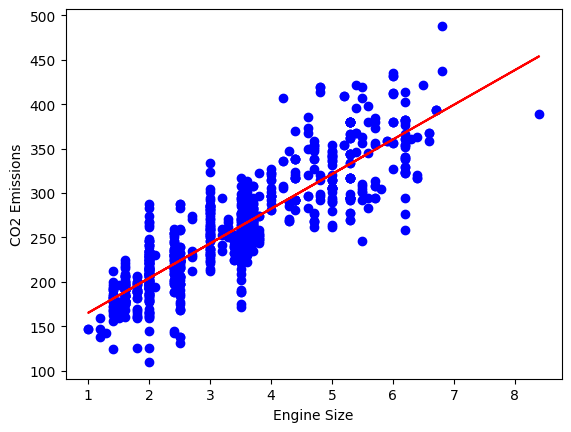

In [ ]:
# visualise regression data
plt.scatter(X_train,y_train,color='blue')
plt.plot(X_train,model.predict(X_train),color='red')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")

Lets train with fuel consumption with co2

In [ ]:
X = cdf[['FUELCONSUMPTION_COMB']]
y = cdf[['CO2EMISSIONS']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
print('m:',model.coef_[0])
print('b:',model.intercept_)

m: [16.18090078]
b: [69.10302618]


In [ ]:
y_fuel_pred = model.predict(X_test)

In [ ]:
print('MAE:',mean_absolute_error(y_test,y_fuel_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_fuel_pred)))
print('R2:',r2_score(y_test,y_fuel_pred))

MAE: 20.441911472549577
RMSE: 28.238885087937177
R2: 0.8071474868274242


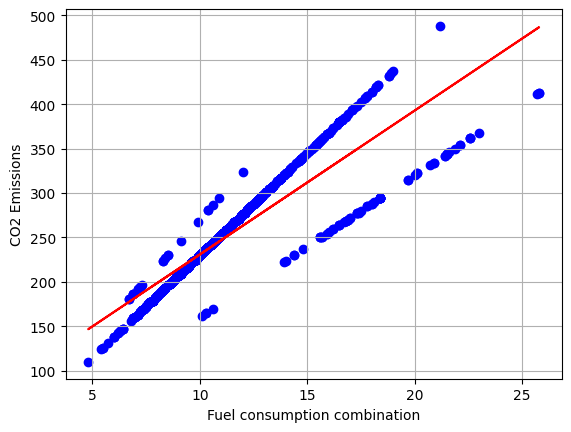

In [ ]:
plt.scatter(X_train,y_train,color='blue')
plt.plot(X_train,model.predict(X_train),color='red')
plt.xlabel('Fuel consumption combination')
plt.ylabel('CO2 Emissions')
plt.grid()

In [ ]:
print(model.intercept_)

[69.10302618]


Train model with Cylinder and CO2

In [ ]:
X = cdf[['CYLINDERS']]
y = cdf[['CO2EMISSIONS']]

In [ ]:
X_train_cylinder,X_test_cylinder, y_train_cylinder, y_test_cylinder = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model.fit(X_train_cylinder,y_train_cylinder)

LinearRegression()

In [ ]:
print('m:',model.coef_[0])
print('b:',model.intercept_)

m: [29.47839879]
b: [86.08850036]


In [ ]:
y_pred_cylinder = model.predict(X_test_cylinder)

In [ ]:
print('MAE:',mean_absolute_error(y_test_cylinder,y_pred_cylinder))
print('RMSE:',np.sqrt(mean_squared_error(y_test_cylinder,y_pred_cylinder)))
print('R2:',r2_score(y_test_cylinder,y_pred_cylinder))

MAE: 25.71492764830526
RMSE: 33.306875797742485
R2: 0.7317140029783895


Lets train all three combined with CO2

In [ ]:
cdf.sample(5)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
466,2.4,4,10.0,230
43,3.0,6,10.9,294
766,5.5,8,15.5,356
361,5.4,8,16.0,368
728,3.5,6,10.6,244


In [ ]:
X= cdf[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]
y= cdf[['CO2EMISSIONS']]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
print('m:',model.coef_)
print('b:',model.intercept_)

m: [[11.2094395   7.15561381  9.5208118 ]]
b: [67.34838518]


In [ ]:
y_pred = model.predict(x_test)

In [ ]:
print('MAE:',mean_absolute_error(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2:',r2_score(y_test,y_pred))

MAE: 16.721593983516485
RMSE: 22.64630515149944
R2: 0.875970520691407


In [ ]:
pri